# Traffic Violation Detection Using YOLOv8 and YOLOv10

## Multi-Seed Comparative Evaluation

This notebook presents the final experimental analysis of a traffic violation object detection study using YOLOv8 and YOLOv10 model variants.

Four YOLO models were evaluated:

- YOLOv8n
- YOLOv8m
- YOLOv10n
- YOLOv10m

Each model was evaluated using three random seeds (42, 123, and 456) to assess performance consistency and robustness.

The notebook focuses on recorded experimental results and comparative analysis. Model training is intentionally excluded from this final analysis notebook.

## check GPU Avaialblity 

In [1]:
import torch
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version (torch):", torch.version.cuda)
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))

Torch: 2.10.0+cu128
CUDA available: True
CUDA version (torch): 12.8
Device: Tesla T4
Capability: (7, 5)


## linking Data set 

In [2]:
import shutil
from pathlib import Path

source = "/kaggle/input/datasets/guisahanes/traffic-violation-detection-dataset"
destination = "/kaggle/working/traffic_dataset"

if Path(destination).exists():
    print("Dataset already copied — skipping.")
else:
    shutil.copytree(source, destination)
    print("Dataset copied successfully")

Dataset already copied — skipping.


## checking the path  

In [3]:
import os

print(os.listdir("/kaggle/working/traffic_dataset"))
print(os.listdir("/kaggle/working/traffic_dataset/images"))

['images', 'labels', 'data.yaml']
['train', 'val']


In [5]:
import ultralytics #Ultralytics is a premier computer vision framework primarily used for developing and deploying YOLO (You Only Look Once) AI models. It is used for real-time object detection, segmentation, pose estimation, tracking, and image classification across various industries. 
print("Installed!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Installed!


# ============================================================
# EXPERIMENT CONTROL
# ============================================================

In [6]:


RUN_TRAINING = False

print("RUN_TRAINING =", RUN_TRAINING)

if RUN_TRAINING:
    print("WARNING: Training is ENABLED.")
else:
    print("Training is DISABLED. Existing experimental results will be used.")

RUN_TRAINING = False
Training is DISABLED. Existing experimental results will be used.


# =========================================
# MASTER CONFIGURATION CELL
# =========================================

In [7]:



from pathlib import Path

from ultralytics import YOLO

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from PIL import Image

import numpy as np
import random
import os
import time
from pathlib import Path
import yaml
import random
import numpy as np

# -----------------------------
# Reproducibility
# -----------------------------


SEEDS = [42, 123, 456]

MODELS_TO_RUN = [
    "yolov8n",
    "yolov8m",
    "yolov10n",
    "yolov10m"
]
DATASET_PATH = Path("/kaggle/working/traffic_dataset")

TRAIN_IMAGES = DATASET_PATH / "images/train"
VAL_IMAGES = DATASET_PATH / "images/val"

# -----------------------------
# Class Names
# -----------------------------

CLASS_NAMES = [
    "person", "car", "truck", "bus", "motorcycle",
    "red light", "green light", "stop sign", "no entry", "no overtaking",
    "speed limit 20", "speed limit 30", "speed limit 40", "speed limit 50",
    "speed limit 60", "speed limit 70", "speed limit 80", "speed limit 100",
    "speed limit 120", "no left turn", "no right turn", "no stopping", "no u-turn"
]

NUM_CLASSES = len(CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)
print("Seeds:", SEEDS)
print("Models:",MODELS_TO_RUN)



Number of classes: 23
Seeds: [42, 123, 456]
Models: ['yolov8n', 'yolov8m', 'yolov10n', 'yolov10m']


# ============================================================
# DATASET YAML CONFIGURATION
# ============================================================

In [8]:
DATA_YAML = {
    "path": str(DATASET_PATH),
    "train": "images/train",
    "val": "images/val",
    "nc": NUM_CLASSES,
    "names": CLASS_NAMES
}

YAML_PATH = "/kaggle/working/fixed.yaml"

with open(YAML_PATH, "w") as f:
    yaml.dump(DATA_YAML, f)

print("Configuration loaded successfully")

import yaml

DATA_YAML = {

    # Writable dataset path
    "path": "/kaggle/working/traffic_dataset",

    # Image folders
    "train": "images/train",
    "val": "images/val",

    # Number of classes
    "nc": 23,

    # Class names
    "names": CLASS_NAMES
}

with open("/kaggle/working/fixed.yaml", "w") as f:
    yaml.dump(DATA_YAML, f)

print("YAML updated successfully")

Configuration loaded successfully
YAML updated successfully


## verification 

In [9]:
import yaml
cfg = yaml.safe_load(open("/kaggle/working/fixed.yaml"))
print("path:", cfg["path"])
print("nc:", cfg["nc"])
print("first classes:", cfg["names"][:5])

path: /kaggle/working/traffic_dataset
nc: 23
first classes: ['person', 'car', 'truck', 'bus', 'motorcycle']


## 4. Recorded Experimental Results

The following results were recorded from the completed multi-seed experiments.

Each model was trained for 100 epochs using the same dataset, image size, batch size, optimizer configuration, and evaluation procedure. Three random seeds (42, 123, and 456) were used for each model.

The results below are treated as the final experimental record for comparative analysis. No model training is performed in this notebook.

In [10]:
import json
RESULTS_JSON = "/kaggle/working/multi_seed_results.json"
multi_seed_results = {
  "yolov8n": {
    "42":  {"status":"done","epoch":100,"mAP50":0.9217,"mAP50_95":0.801,"precision":0.8992,"recall":0.8769,"train_min":99.35,"gpu_mb":1941.0,"fps":56.2,"model_size_mb":5.95,"resumed":False,"best_pt":None},
    "123": {"status":"done","epoch":100,"mAP50":0.9126744292338356,"mAP50_95":0.7956577206943807,"precision":0.9010274851613601,"recall":0.868209856647483,"train_min":102.99,"gpu_mb":2001.19,"fps":55.49,"model_size_mb":5.95,"resumed":False,"best_pt":None},
    "456": {"status":"done","epoch":100,"mAP50":0.9102228729497827,"mAP50_95":0.7889348706684839,"precision":0.8762814053287613,"recall":0.8854742417093818,"train_min":103.65,"gpu_mb":2014.09,"fps":97.9,"model_size_mb":5.95,"resumed":False,"best_pt":None},
  },
  "yolov8m": {
    "42":  {"status":"done","epoch":100,"mAP50":0.9277,"mAP50_95":0.8048,"precision":0.9042,"recall":0.8933,"train_min":110.0,"gpu_mb":4200.0,"fps":31.1,"model_size_mb":49.62,"resumed":False,"best_pt":None},
    "123": {"status":"done","epoch":100,"mAP50":0.9223596899075864,"mAP50_95":0.8061763613292017,"precision":0.9048153843858249,"recall":0.8786341870221,"train_min":369.36,"gpu_mb":5879.97,"fps":35.52,"model_size_mb":49.62,"resumed":False,"best_pt":None},
    "456": {"status":"done","epoch":100,"mAP50":0.9207784734287606,"mAP50_95":0.7985678275650745,"precision":0.872803611645864,"recall":0.9045370794691818,"train_min":276.26,"gpu_mb":5815.89,"fps":34.86,"model_size_mb":49.62,"resumed":False,"best_pt":None},
  },
  "yolov10n": {
    "42":  {"status":"done","epoch":100,"mAP50":0.9029,"mAP50_95":0.79,"precision":0.8916,"recall":0.8329,"train_min":130.87,"gpu_mb":2738.0,"fps":53.68,"model_size_mb":5.48,"resumed":False,"best_pt":None},
    "123": {"status":"done","epoch":100,"mAP50":0.9049718059227084,"mAP50_95":0.7881577897219927,"precision":0.882383809135337,"recall":0.8480963627403638,"train_min":140.87,"gpu_mb":2640.85,"fps":50.85,"model_size_mb":5.48,"resumed":False,"best_pt":None},
    "456": {"status":"done","epoch":100,"mAP50":0.8963843414797418,"mAP50_95":0.7804499984027643,"precision":0.9040405419336293,"recall":0.8246487147409894,"train_min":137.94,"gpu_mb":2667.69,"fps":84.87,"model_size_mb":5.48,"resumed":False,"best_pt":None},
  },
  "yolov10m": {
    "42":  {"status":"done","epoch":100,"mAP50":0.9233,"mAP50_95":0.8088,"precision":0.9241,"recall":0.8774,"train_min":380.61,"gpu_mb":7879.0,"fps":37.47,"model_size_mb":31.95,"resumed":False,"best_pt":None},
    "123": {"status":"done","epoch":100,"mAP50":0.915199882524118,"mAP50_95":0.8052487338345568,"precision":0.8880424496487005,"recall":0.8905461855914251,"train_min":387.02,"gpu_mb":7811.08,"fps":34.56,"model_size_mb":31.95,"resumed":False,"best_pt":None},
    "456": {"status":"done","epoch":100,"mAP50":0.924,"mAP50_95":0.807,"precision":0.895,"recall":0.889,"train_min":407.88,"gpu_mb":7879.0,"fps":37.92,"model_size_mb":31.95,"resumed":False,"best_pt":"/kaggle/working/Traffic_MultiSeed/yolov10m_seed456/weights/best.pt"},
  },
}
with open(RESULTS_JSON, "w") as f:
    json.dump(multi_seed_results, f, indent=2)
print("Restored. Done seeds per model:")
for m, s in multi_seed_results.items():
    print(f"  {m}: {[k for k,v in s.items() if v['status']=='done']}")

Restored. Done seeds per model:
  yolov8n: ['42', '123', '456']
  yolov8m: ['42', '123', '456']
  yolov10n: ['42', '123', '456']
  yolov10m: ['42', '123', '456']


# Training 

In [12]:
from ultralytics import YOLO
import time
import torch
import gc
import os
import json

# ============================================================
# SETTINGS
# ============================================================


DATA_YAML = "/kaggle/working/fixed.yaml"
PROJECT = "/kaggle/working/Traffic_MultiSeed"
RESULTS_JSON = "/kaggle/working/multi_seed_results.json"


# ============================================================
# LOAD EXISTING RESULTS
# ============================================================

if os.path.exists(RESULTS_JSON):

    with open(RESULTS_JSON, "r") as f:
        multi_seed_results = json.load(f)

    print("✓ Existing results JSON loaded.")

else:

    multi_seed_results = {}

    print("⚠ Results JSON not found. Training will be performed.")


# ============================================================
# MODEL + SEED LOOP
# ============================================================

for model_name in MODELS_TO_RUN:

    model_short = model_name.replace(".pt", "")

    for seed in SEEDS:

        seed_key = str(seed)

        print("\n" + "=" * 70)
        print(f"Model: {model_short}")
        print(f"Seed : {seed}")
        print("=" * 70)


        # ====================================================
        # CHECK JSON FIRST
        # ====================================================

        if (
            model_short in multi_seed_results
            and seed_key in multi_seed_results[model_short]
            and multi_seed_results[model_short][seed_key].get("status") == "done"
        ):

            print("✓ Results found in JSON.")
            print("→ Training skipped.")

            continue


        # ====================================================
        # TRAIN ONLY IF NOT ALREADY DONE
        # ====================================================

        print("✗ Results not found / incomplete.")
        print("→ Starting training...")


        torch.cuda.empty_cache()
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()

        t0 = time.perf_counter()


        model = YOLO(model_name)

        model.train(
            data=DATA_YAML,
            epochs=100,
            imgsz=640,
            batch=16,
            optimizer="SGD",
            lr0=0.01,
            momentum=0.937,
            patience=20,
            close_mosaic=10,
            cache=True,
            workers=2,
            device=0,
            seed=seed,
            project=PROJECT,
            name=f"{model_short}_seed{seed}",
            exist_ok=True,
        )


        train_minutes = (time.perf_counter() - t0) / 60

        if torch.cuda.is_available():
            gpu_mb = (
                torch.cuda.max_memory_allocated()
                / (1024 ** 2)
            )
        else:
            gpu_mb = None


        # ====================================================
        # VALIDATION
        # ====================================================

        metrics = model.val(
            data=DATA_YAML,
            imgsz=640,
            batch=16,
            device=0
        )


        # ====================================================
        # EXTRACT METRICS
        # ====================================================

        precision = float(metrics.box.mp)
        recall = float(metrics.box.mr)
        map50 = float(metrics.box.map50)
        map50_95 = float(metrics.box.map)


        # ====================================================
        # BEST MODEL
        # ====================================================

        best_pt = os.path.join(
            PROJECT,
            f"{model_short}_seed{seed}",
            "weights",
            "best.pt"
        )


        # ====================================================
        # MODEL SIZE
        # ====================================================

        if os.path.exists(best_pt):

            model_size_mb = (
                os.path.getsize(best_pt)
                / (1024 ** 2)
            )

        else:

            model_size_mb = None


        # ====================================================
        # UPDATE JSON
        # ====================================================

        if model_short not in multi_seed_results:
            multi_seed_results[model_short] = {}

        multi_seed_results[model_short][seed_key] = {

            "status": "done",

            "epoch": 100,

            "mAP50": map50,

            "mAP50_95": map50_95,

            "precision": precision,

            "recall": recall,

            "train_min": round(train_minutes, 2),

            "gpu_mb": round(gpu_mb, 2)
                if gpu_mb is not None else None,

            "fps": None,

            "model_size_mb": round(model_size_mb, 2)
                if model_size_mb is not None else None,

            "resumed": False,

            "best_pt": best_pt
                if os.path.exists(best_pt) else None
        }


        # Save immediately
        with open(RESULTS_JSON, "w") as f:
            json.dump(
                multi_seed_results,
                f,
                indent=2
            )


        print("✓ Training completed and results saved.")


        # ====================================================
        # CLEAN MEMORY
        # ====================================================

        del model
        del metrics

        gc.collect()
        torch.cuda.empty_cache()


print("\n" + "=" * 70)
print("DONE")
print("=" * 70)

✓ Existing results JSON loaded.

Model: yolov8n
Seed : 42
✓ Results found in JSON.
→ Training skipped.

Model: yolov8n
Seed : 123
✓ Results found in JSON.
→ Training skipped.

Model: yolov8n
Seed : 456
✓ Results found in JSON.
→ Training skipped.

Model: yolov8m
Seed : 42
✓ Results found in JSON.
→ Training skipped.

Model: yolov8m
Seed : 123
✓ Results found in JSON.
→ Training skipped.

Model: yolov8m
Seed : 456
✓ Results found in JSON.
→ Training skipped.

Model: yolov10n
Seed : 42
✓ Results found in JSON.
→ Training skipped.

Model: yolov10n
Seed : 123
✓ Results found in JSON.
→ Training skipped.

Model: yolov10n
Seed : 456
✓ Results found in JSON.
→ Training skipped.

Model: yolov10m
Seed : 42
✓ Results found in JSON.
→ Training skipped.

Model: yolov10m
Seed : 123
✓ Results found in JSON.
→ Training skipped.

Model: yolov10m
Seed : 456
✓ Results found in JSON.
→ Training skipped.

DONE


## CELL A-3: COMPUTE AND DISPLAY MEAN ± STD

In [13]:
# =========================================
# CELL A-3: COMPUTE AND DISPLAY MEAN ± STD
# =========================================
import pandas as pd

summary_rows = []

for model_name in MODELS_TO_RUN:
    seed_data = multi_seed_results.get(model_name, {})
    if not seed_data:
        print(f"WARNING: No results for {model_name}")
        continue

    metrics_list = list(seed_data.values())

    for metric in ["mAP50", "mAP50_95", "precision", "recall",
                   "train_min", "gpu_mb", "fps", "model_size_mb"]:
        vals = np.array([r[metric] for r in metrics_list if metric in r])
        if len(vals) == 0:
            continue
        summary_rows.append({
            "Model":  model_name,
            "Metric": metric,
            "Mean":   round(vals.mean(), 4),
            "Std":    round(vals.std(),  4),
            "Min":    round(vals.min(),  4),
            "Max":    round(vals.max(),  4),
            "Runs":   len(vals),
        })

df_summary = pd.DataFrame(summary_rows)

# ── Publication table ──
pub_rows = []
for model_name in MODELS_TO_RUN:
    row = {"Model": model_name}
    sub = df_summary[df_summary["Model"] == model_name]
    for _, r in sub.iterrows():
        row[r["Metric"]] = f"{r['Mean']:.4f} ± {r['Std']:.4f}"
    pub_rows.append(row)

df_pub = pd.DataFrame(pub_rows)
print("\n=== PUBLICATION TABLE: Mean ± Std across", len(SEEDS), "seeds ===")
print(df_pub.to_string(index=False))

df_pub.to_csv("/kaggle/working/multi_seed_summary.csv", index=False)
print("\nSaved: /kaggle/working/multi_seed_summary.csv")


=== PUBLICATION TABLE: Mean ± Std across 3 seeds ===
   Model           mAP50        mAP50_95       precision          recall           train_min               gpu_mb               fps    model_size_mb
 yolov8n 0.9149 ± 0.0049 0.7952 ± 0.0049 0.8922 ± 0.0113 0.8769 ± 0.0070   101.9967 ± 1.8908  1985.4267 ± 31.8528 69.8633 ± 19.8270  5.9500 ± 0.0000
 yolov8m 0.9236 ± 0.0030 0.8032 ± 0.0033 0.8939 ± 0.0149 0.8922 ± 0.0106 251.8733 ± 107.2783 5298.6200 ± 777.2820  33.8267 ± 1.9468 49.6200 ± 0.0000
yolov10n 0.9014 ± 0.0037 0.7862 ± 0.0041 0.8927 ± 0.0089 0.8352 ± 0.0097   136.5600 ± 4.1975  2682.1800 ± 40.9634 63.1333 ± 15.4135  5.4800 ± 0.0000
yolov10m 0.9208 ± 0.0040 0.8070 ± 0.0014 0.9024 ± 0.0156 0.8856 ± 0.0059  391.8367 ± 11.6423  7856.3600 ± 32.0178  36.6500 ± 1.4892 31.9500 ± 0.0000

Saved: /kaggle/working/multi_seed_summary.csv


## 2A-4: PLOT — Mean ± Std BAR CHART

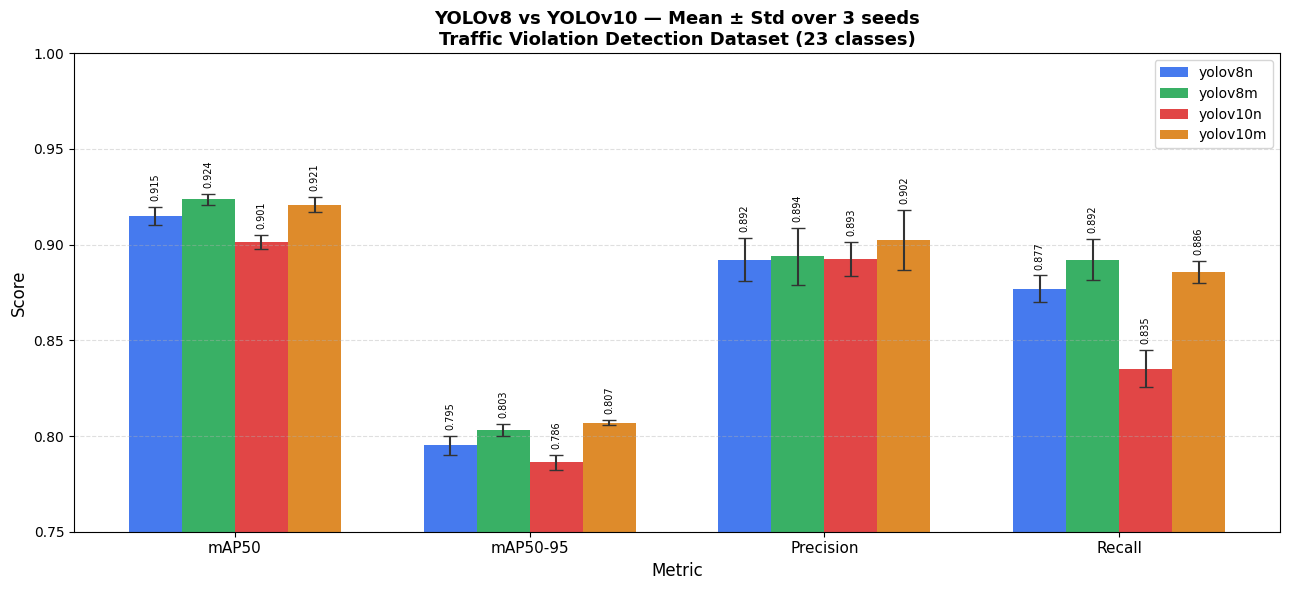

Saved: multi_seed_barplot.png


In [15]:
# =========================================
# CELL A-4: PLOT — Mean ± Std BAR CHART
# =========================================
import matplotlib.pyplot as plt
import numpy as np

metrics_to_plot = ["mAP50", "mAP50_95", "precision", "recall"]
metric_labels   = ["mAP50", "mAP50-95", "Precision", "Recall"]

# MODELS_TO_RUN is a LIST
model_names = [m.replace(".pt", "") for m in MODELS_TO_RUN]

colors = ["#2563eb", "#16a34a", "#dc2626", "#d97706"]

x     = np.arange(len(metrics_to_plot))
width = 0.18

fig, ax = plt.subplots(figsize=(13, 6))

for i, model_name in enumerate(model_names):

    sub = df_summary[df_summary["Model"] == model_name]

    means = []
    stds = []

    for m in metrics_to_plot:
        row = sub[sub["Metric"] == m]

        means.append(float(row["Mean"].iloc[0]))
        stds.append(float(row["Std"].iloc[0]))

    offset = (i - 1.5) * width

    bars = ax.bar(
        x + offset,
        means,
        width,
        label=model_name,
        color=colors[i],
        alpha=0.85,
        yerr=stds,
        capsize=5,
        error_kw=dict(
            elinewidth=1.5,
            ecolor="#333"
        )
    )

    # Value labels
    for bar, mean, std in zip(bars, means, stds):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std + 0.003,
            f"{mean:.3f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

ax.set_xlabel("Metric", fontsize=12)
ax.set_ylabel("Score", fontsize=12)

ax.set_title(
    f"YOLOv8 vs YOLOv10 — Mean ± Std over {len(SEEDS)} seeds\n"
    "Traffic Violation Detection Dataset (23 classes)",
    fontsize=13,
    fontweight="bold"
)

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11)

ax.set_ylim(0.75, 1.0)

ax.legend(fontsize=10)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/multi_seed_barplot.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved: multi_seed_barplot.png")